In [2]:
import yfinance as yf
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers, callbacks
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as p1t
from warnings import filterwarnings
plt.style.use('fivethirtyeight')
filterwarnings('ignore')
print("Libraries Imported Successfully!")

Libraries Imported Successfully!


Data Loaded Successfully!
Data Shape: (3262, 5)
Last Date: 2025-12-19 00:00:00
Price             Price
Date                   
2025-12-15  4306.700195
2025-12-16  4304.500000
2025-12-17  4347.500000
2025-12-18  4339.500000
2025-12-19  4361.399902


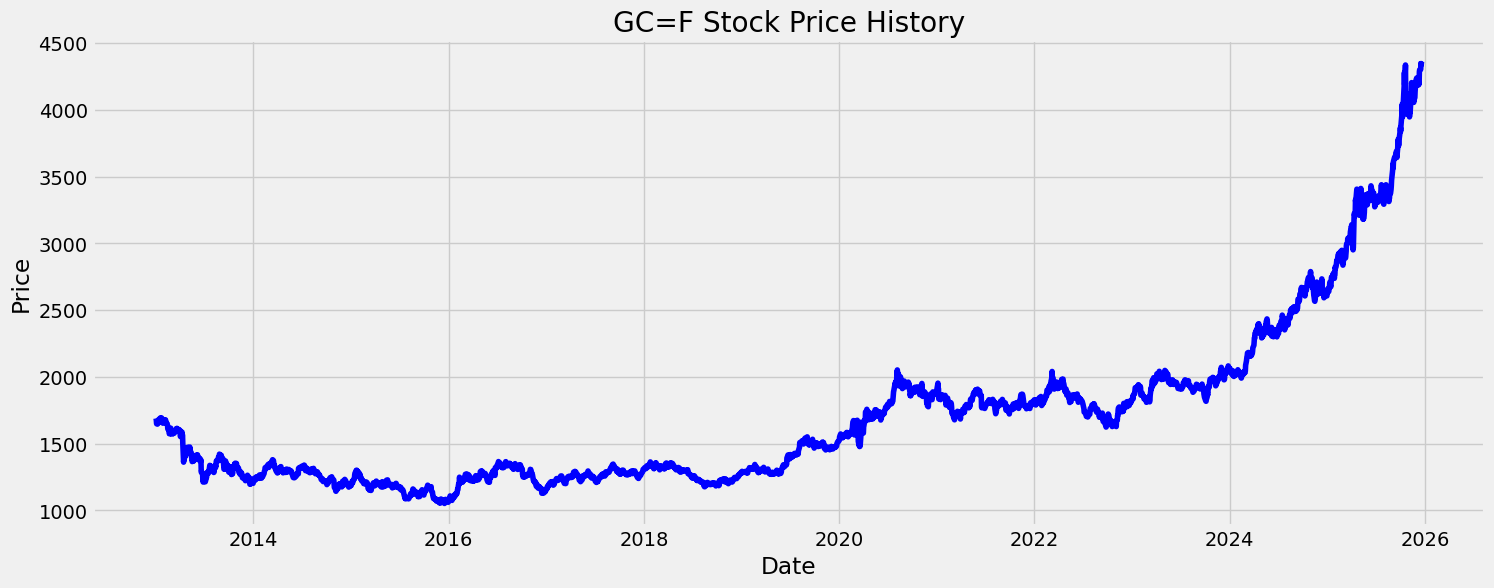

In [ ]:
ticker = 'GC=F'
try:
    data = yf.download(ticker, start='2013-01-01', progress=False)
except Exception as e:
    print(f"Error downloading data: {e}")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data.reset_index(inplace=True)

if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'])
    data = data.set_index('Date')
elif 'Datetime' in data.columns:
    data['Datetime'] = pd.to_datetime(data['Datetime'])
    data = data.set_index('Datetime')


if 'Close' in data.columns:
    data.rename(columns={'Close': 'Price'}, inplace=True)
elif 'Adj Close' in data.columns:
    data.rename(columns={'Adj Close': 'Price'}, inplace=True)
else:
    print("Columns found:", data.columns)
    raise ValueError("Could not find 'Close' or 'Adj Close' column in data!")

data.dropna(subset=['Price'], inplace=True)

print(f"Data Loaded Successfully!")
print(f"Data Shape: {data.shape}")
print(f"Last Date: {data.index[-1]}")
print(data[['Price']].tail())

# رسم السعر
plt.figure(figsize=(16,6))
plt.plot(data['Price'], color='blue')
plt.title(f'{ticker} Stock Price History')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [ ]:
features = data['Price'].values.reshape(-1,1)

train_size = int(len(features) * 0.8)
test_size = len(features) - train_size

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(features)

training = scaled_data[:train_size]
time_steps = 60
x_train, y_train = [], []

for i in range(time_steps, len(training)):
    x_train.append(training[i-time_steps:i, 0])
    y_train.append(training[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

test_features = scaled_data[train_size - time_steps:]
x_test, y_test = [], []

for i in range(time_steps, len(test_features)):
    x_test.append(test_features[i-time_steps:i, 0])
    y_test.append(test_features[i, 0])

x_test = np.array(x_test)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)
y_test = np.array(y_test)

print(f'Train Shape: {x_train.shape}, Test Shape: {x_test.shape}')

Train Shape: (2549, 60, 1), Test Shape: (653, 60, 1)


In [ ]:
model = models.Sequential([
    layers.LSTM(50, return_sequences=True, input_shape=(x_train.shape[1],1)),
    layers.Dropout(0.2),

    layers.LSTM(50, return_sequences=True),
    layers.Dropout(0.2),

    layers.LSTM(50, return_sequences=False),
    layers.Dropout(0.2),

    layers.Dense(25, activation='relu'),
    layers.Dense(1, activation='linear')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, loss='mse', metrics=['mean_absolute_error'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,101 (203.52 KB)

 Trainable params: 52,101 (203.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 127ms/step - loss: 0.0061 - mean_absolute_error: 0.0527
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 3.4331e-04 - mean_absolute_error: 0.0135
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - loss: 2.4493e-04 - mean_absolute_error: 0.0114
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 2.6145e-04 - mean_absolute_error: 0.0117
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 2.1774e-04 - mean_absolute_error: 0.0108
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - loss: 1.8663e-04 - mean_absolute_error: 0.0100
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 1.9191e-04 - mean_absolute_error: 0.0103
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 1.7761e-04 - mean_absolute_error: 0.0098
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 2.1564e-04 - mean_absolute_error: 0.0111
Epoch 10/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 1.5981e-04 - mean_absolute_error: 0.0094


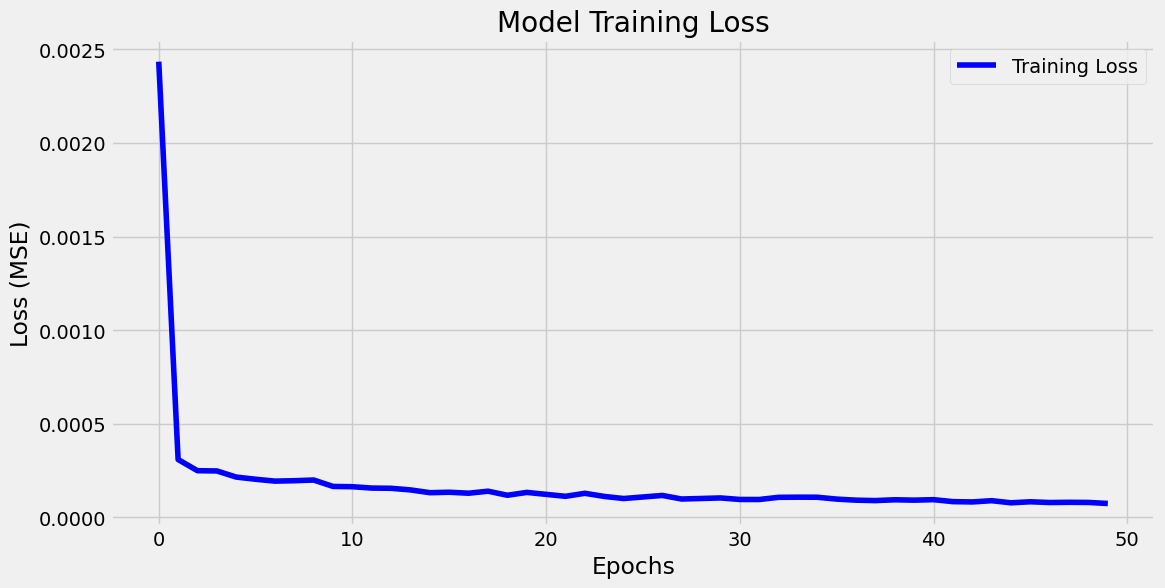

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]
)

plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.title("Model Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

In [ ]:

predictions = model.predict(x_test)
predictions_real = scaler.inverse_transform(predictions)
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))


rmse = np.sqrt(np.mean((y_test_real - predictions_real)**2))

mape = np.mean(np.abs((y_test_real - predictions_real) / y_test_real)) * 100

accuracy = 100 - mape

print("\n---------------- Model Performance ----------------")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} EGP")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Model Accuracy (Approx): {accuracy:.2f}%")
print("---------------------------------------------------")

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step

---------------- Model Performance ----------------
Root Mean Squared Error (RMSE): 237.49 EGP
Mean Absolute Percentage Error (MAPE): 5.45%
Model Accuracy (Approx): 94.55%
---------------------------------------------------


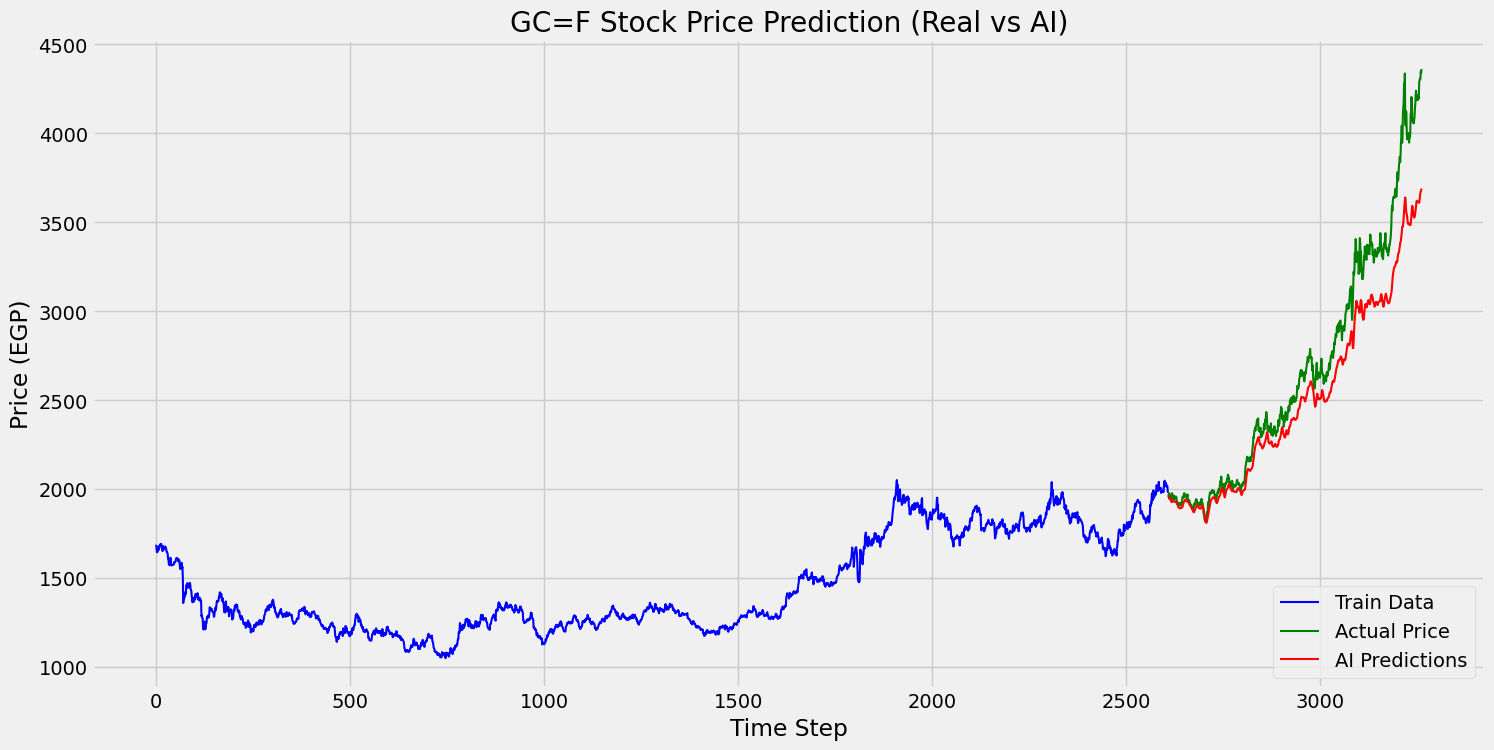

In [ ]:
train_df = pd.DataFrame(features[:train_size], columns=['Price'])
test_df = pd.DataFrame(features[train_size:], columns=['Price'])

test_df.index = range(train_size, train_size + len(test_df))

test_df['Predictions'] = np.nan

num_preds = len(predictions_real.flatten())
test_df.iloc[-num_preds:, test_df.columns.get_loc('Predictions')] = predictions_real.flatten()

plt.figure(figsize=(16,8))
plt.plot(train_df['Price'], label='Train Data', color='blue', linewidth=1.5)
plt.plot(test_df['Price'], label='Actual Price', color='green', linewidth=1.5)
plt.plot(test_df['Predictions'], label='AI Predictions', color='red', linewidth=1.5)

plt.title(f'{ticker} Stock Price Prediction (Real vs AI)')
plt.xlabel('Time Step')
plt.ylabel('Price (EGP)')
plt.legend(loc='lower right')
plt.show()

In [ ]:

flat_real = y_test_real.flatten()
flat_pred = predictions_real.flatten()

min_len = min(len(flat_real), len(flat_pred))

comparison_df = pd.DataFrame({
    'Actual_Price': flat_real[-min_len:],
    'Predicted_Price': flat_pred[-min_len:]
})

comparison_df['Diff (EGP)'] = comparison_df['Actual_Price'] - comparison_df['Predicted_Price']
comparison_df['Error %'] = (abs(comparison_df['Diff (EGP)']) / comparison_df['Actual_Price']) * 100

comparison_df.index = data.index[-min_len:]
comparison_df.index.name = 'Date'

pd.options.display.float_format = '{:.2f}'.format

print(comparison_df.head(5))




print(f"(Max Error): {comparison_df['Diff (EGP)'].abs().max():.2f} EGP")
print(f"(Avg Error %): {comparison_df['Error %'].mean():.2f}%")



NameError: name 'y_test_real' is not defined